# Proyecto Reversi: Análisis de Resultados del Benchmark

## 1. Objetivo

El objetivo de este cuaderno es presentar y analizar sistemáticamente los resultados del benchmark realizado a nuestro agente de IA para el juego de Reversi.

Este análisis se enfoca en evaluar el rendimiento del algoritmo Minimax bajo las distintas configuraciones y escenarios de prueba definidos en los requerimientos del proyecto (Sección 2.2). Se comparará el desempeño del agente variando sus heurísticas, configuraciones de pesos y límites de tiempo, mientras se enfrenta a un conjunto diverso de oponentes (aleatorio, greedy, peor decisión, humano y otra IA).

Las métricas clave para esta evaluación serán: el ganador de la partida, la cantidad de puntos finales, los nodos expandidos, la profundidad de búsqueda y el tiempo de ejecución.


## Miembros del Grupo 3
* Deybby Rosario
* Sarah Peña
* Carlos Roa
* Héctor Reyes
---

## 2. Generación de Datos del Benchmark

Para obtener los datos que se analizan en este cuaderno, se desarrolló un script de automatización en Python. Este script se encargó de ejecutar de forma sistemática todas las partidas de Reversi requeridas para el benchmark.

El proceso consistió en:

1.  **Definir Agentes de IA:** Se instanciaron las 9 configuraciones del agente `MinimaxPlayer` a probar, variando:
    * Dos configuraciones de pesos de heurísticas.
    * Cinco configuraciones incrementales de heurísticas (de 1 a 5).
    * Dos configuraciones de tiempo máximo (3 y 10 segundos).

2.  **Definir Oponentes:** Se crearon los tipos de contrincantes base: Aleatorio, Greedy, Peor Decisión y una IA base (usada para las pruebas IA vs. IA).

3.  **Ejecutar Partidas:** El script generó todas las combinaciones de partidas entre los agentes de IA y los oponententes.

4.  **Ejecución en Paralelo:** Para acelerar la recolección de datos, el script utilizó el módulo `concurrent.futures.ProcessPoolExecutor` para correr múltiples partidas de forma simultánea.

5.  **Recolección de Métricas:** Al finalizar cada juego, la función `play_match` capturó las métricas de rendimiento estipuladas (Ganador, Puntos, Nodos Expandidos, Profundidad y Tiempo) y las almacenó.

El conjunto de todos estos resultados se consolidó en un único archivo de datos, el cual se importará para su análisis.


### 3. Carga y Análisis Exploratorio de Datos

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
file_name = 'benchmark reversi.csv'

# Cargar el archivo CSV en un DataFrame
df_benchmark = pd.read_csv(file_name)

In [5]:
df_benchmark.head()

,player_name,opponent,winner,points,Total_points,turns,total_nodes_expanded,total_search_depth,total_running_time,total_max_ram_usage
0,weights_2,weights_1,weights_2,43,64,30,40.83,1.20,1.03,0.52
1,weights_2,heuristic_1,weights_2,39,62,30,24.87,1.00,1.02,0.56
2,weights_2,heuristic_4,weights_2,42,62,30,44.13,1.33,1.02,0.54
3,weights_2,heuristic_2,weights_2,58,62,30,39.27,1.67,1.02,0.52
4,weights_2,heuristic_5,heuristic_5,30,64,30,40.37,1.10,1.02,0.54


In [7]:
print("\n--- Información y estructura del DataFrame ---")
df_benchmark.info()


--- Información y estructura del DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135 entries, 0 to 134
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   player_name           135 non-null    object 
 1   opponent              135 non-null    object 
 2   winner                135 non-null    object 
 3   points                135 non-null    int64  
 4   Total_points          135 non-null    int64  
 5   turns                 135 non-null    int64  
 6   total_nodes_expanded  135 non-null    float64
 7   total_search_depth    135 non-null    float64
 8   total_running_time    135 non-null    float64
 9   total_max_ram_usage   135 non-null    float64
dtypes: float64(4), int64(3), object(3)
memory usage: 10.7+ KB


In [12]:
print("\n--- Resumen estadístico (columnas numéricas) ---")
df_benchmark.describe(include='all').round(2) # para ver también un resumen de las columnas no numéricas


--- Resumen estadístico (columnas numéricas) ---


,player_name,opponent,winner,points,Total_points,turns,total_nodes_expanded,total_search_depth,total_running_time,total_max_ram_usage
count,135,135,135,135.00,135.00,135.00,135.00,135.00,135.00,135.00
unique,12,13,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,weights_2,weights_1,heuristic_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,12,11,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,32.10,62.42,29.26,64.55,1.50,1.93,0.69
std,NaN,NaN,NaN,14.32,2.80,1.71,82.20,0.64,2.61,0.47
min,NaN,NaN,NaN,0.00,51.00,21.00,6.21,0.93,0.04,0.05
25%,NaN,NaN,NaN,21.00,62.00,29.00,32.56,1.12,1.02,0.52
50%,NaN,NaN,NaN,33.00,63.00,30.00,38.30,1.27,1.02,0.55
75%,NaN,NaN,NaN,43.00,64.00,30.00,44.22,1.61,1.03,0.61


#### 3.1. Notas de Hallazgos Clave

El resumen estadístico inicial nos proporciona una visión general de las partidas ejecutadas:

- **Total de Partidas:** Se analizaron 135 partidas completas. No se detectaron valores nulos en ninguna columna, lo que indica un conjunto de datos limpio.

- **Ganador Más Frecuente:** El agente heuristic_2 (Minimax con 2 heurísticas) fue el ganador más frecuente de todo el benchmark, logrando 17 victorias.


> **Duración de las Partidas (Puntos y Turnos):**

1. En promedio, el jugador principal (player_name) obtuvo 32.1 puntos. El rango fue amplio, desde 0 hasta 58 puntos.

2. Las partidas finalizaron, de media, con 62.42 de 64 casillas ocupadas, lo que indica que la mayoría de los juegos llegaron a un estado de tablero casi lleno.

3. La duración media fue de 29.26 turnos por jugador.

> **Rendimiento y Tiempos de Cómputo:**

1.  **Tiempo de Ejecución (total_running_time):** La media fue de 1.93 segundos. Sin embargo, la mediana (50%) es de 1.02 segundos. Esto revela que la mayoría de las configuraciones (las que tenían max_time=1) operaron consistentemente cerca de su límite, mientras que las configuraciones de 3 y 10 segundos (que alcanzan el máximo de 10.03s) elevan la media.

2. **Nodos Expandidos (total_nodes_expanded):** Esta métrica muestra una enorme variabilidad. Aunque la media es de 64.55 nodos, la desviación estándar es muy alta (82.2) y el rango va desde 6.21 hasta 446.59. Esto sugiere fuertemente que las configuraciones con más tiempo (time_3, time_10) exploraron árboles de búsqueda exponencialmente más grandes que el resto.

3. **Profundidad de Búsqueda (total_search_depth):** La profundidad media alcanzada fue de 1.5. La mayoría de las búsquedas (75%) no superaron una profundidad de 1.61, lo que indica que el límite de 1 segundo es una restricción significativa.

4. **Uso de Memoria (total_max_ram_usage):** El algoritmo fue eficiente en memoria, con un uso medio de 0.69 (unidades) y un pico máximo de solo 2.48, indicando que la memoria no fue un cuello de botella.

### 4. Visualización de Hallazgos

#### 4.1. Frecuencia de Victorias (Ganador del Juego)

El primer hallazgo fue que heuristic_2 fue el ganador más frecuente. Crearemos un gráfico de barras horizontales para visualizar las victorias de cada uno de nuestros agentes de IA. Esto nos permitirá confirmar qué configuración fue la dominante.

Gráfico 'frecuencia_victorias_ia.png' guardado.


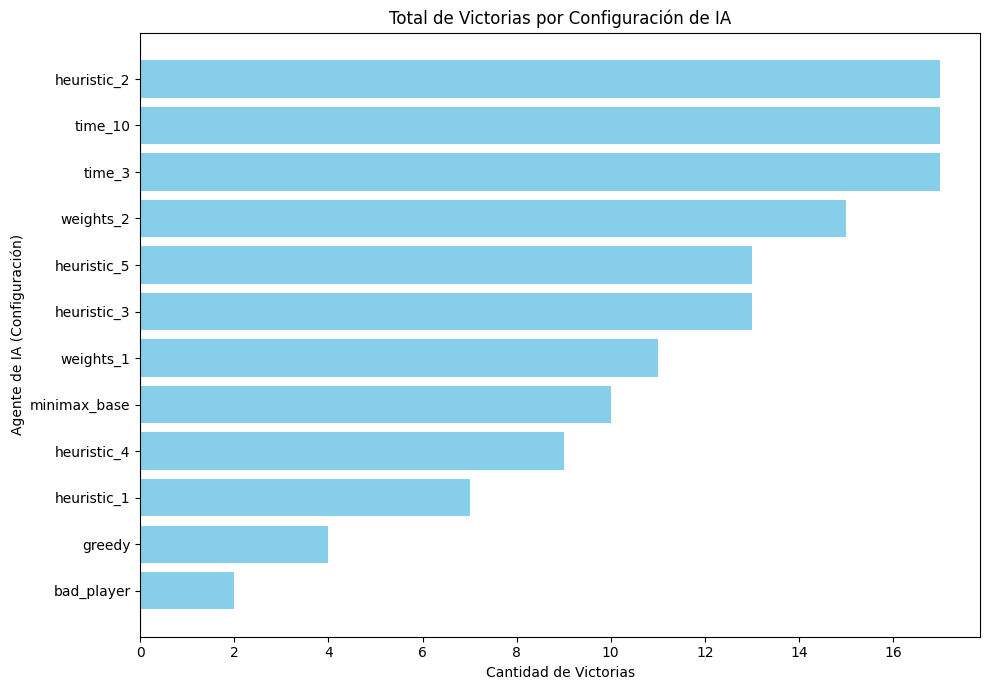

In [14]:
# 1. Obtener la lista de nuestros agentes de IA
player_list = df_benchmark['player_name'].unique()

# 2. Filtrar el dataframe para contar solo cuando el ganador es uno de nuestros agentes
df_wins = df_benchmark[df_benchmark['winner'].isin(player_list)]

# 3. Contar las victorias
win_counts = df_wins['winner'].value_counts()

# 4. Crear el gráfico de barras horizontales
plt.figure(figsize=(10, 7))
plt.barh(win_counts.index, win_counts.values, color='skyblue')

# Añadir títulos y etiquetas
plt.xlabel('Cantidad de Victorias')
plt.ylabel('Agente de IA (Configuración)')
plt.title('Total de Victorias por Configuración de IA')

# Invertir el eje Y para mostrar el ganador principal en la parte superior
plt.gca().invert_yaxis()

# Optimizar el espacio
plt.tight_layout()

# Guardar la imagen
plt.savefig('frecuencia_victorias_ia.png')

# Imprimir un mensaje de confirmación
print("Gráfico 'frecuencia_victorias_ia.png' guardado.")

#### 4.2. Distribución de Recursos (Tiempo, Nodos, Profundidad y RAM)

El segundo grupo de hallazgos se relacionó con la gran variabilidad en el tiempo de ejecución y los nodos expandidos, y el bajo uso de profundidad y RAM.

Un panel de histogramas (un gráfico 2x2) es la forma más efectiva de visualizar estas cuatro distribuciones de una sola vez y confirmar las medianas, medias y la presencia de valores atípicos (skewness).

Gráfico 'distribucion_recursos.png' guardado.


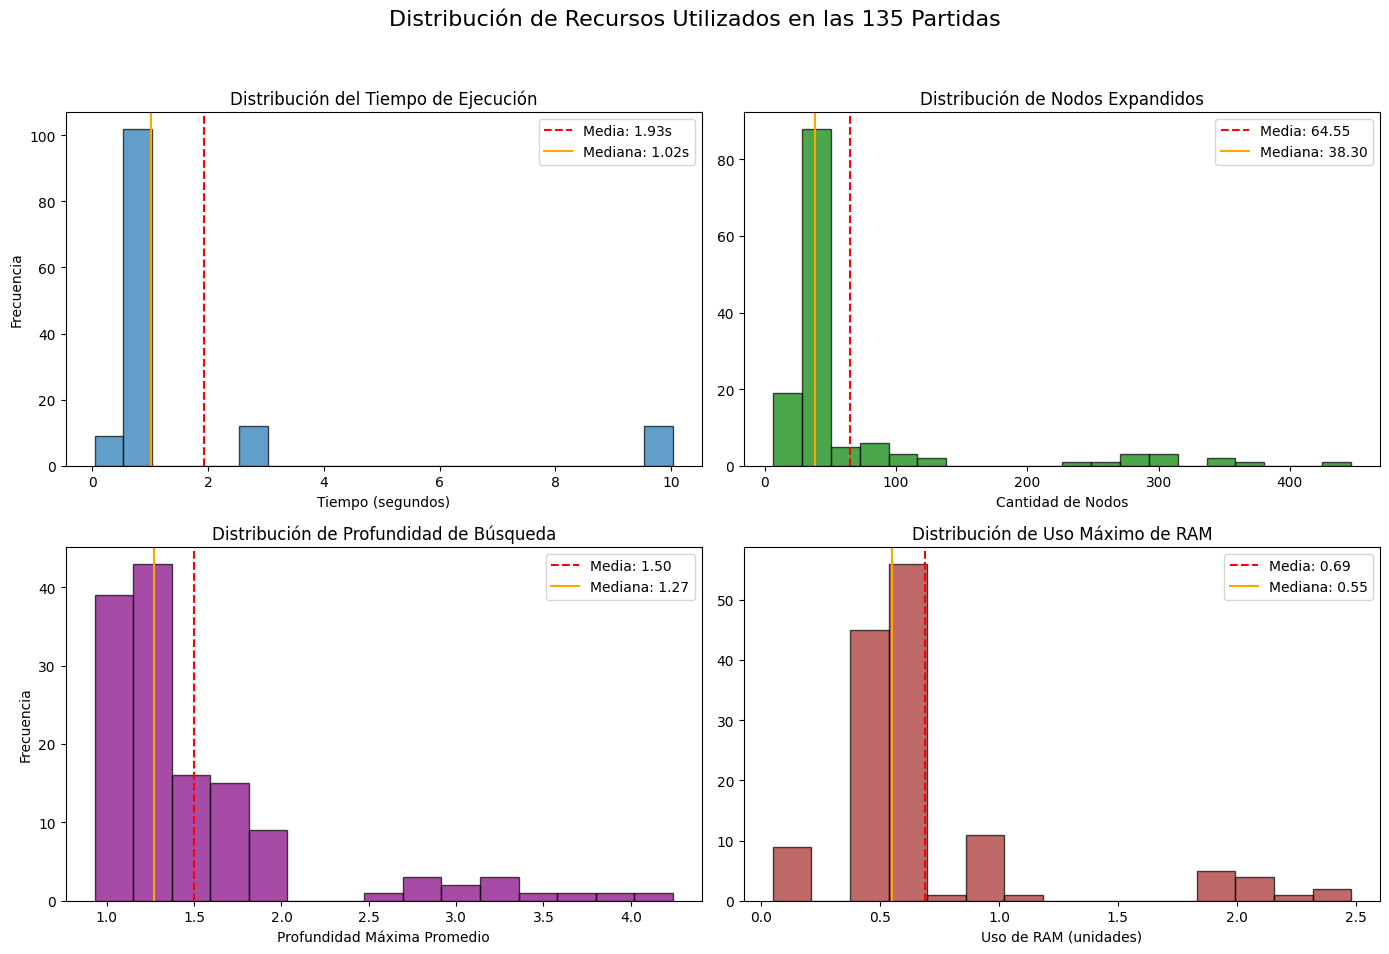

In [15]:
# Crear un panel de histogramas (2x2)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución de Recursos Utilizados en las 135 Partidas', fontsize=16)

# --- Gráfico 1: Tiempo de Ejecución ---
axes[0, 0].hist(df_benchmark['total_running_time'], bins=20, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribución del Tiempo de Ejecución')
axes[0, 0].set_xlabel('Tiempo (segundos)')
axes[0, 0].set_ylabel('Frecuencia')
# Añadir línea de media y mediana
axes[0, 0].axvline(df_benchmark['total_running_time'].mean(), color='red', linestyle='--', label=f"Media: {df_benchmark['total_running_time'].mean():.2f}s")
axes[0, 0].axvline(df_benchmark['total_running_time'].median(), color='orange', linestyle='-', label=f"Mediana: {df_benchmark['total_running_time'].median():.2f}s")
axes[0, 0].legend()

# --- Gráfico 2: Nodos Expandidos ---
axes[0, 1].hist(df_benchmark['total_nodes_expanded'], bins=20, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_title('Distribución de Nodos Expandidos')
axes[0, 1].set_xlabel('Cantidad de Nodos')
axes[0, 1].axvline(df_benchmark['total_nodes_expanded'].mean(), color='red', linestyle='--', label=f"Media: {df_benchmark['total_nodes_expanded'].mean():.2f}")
axes[0, 1].axvline(df_benchmark['total_nodes_expanded'].median(), color='orange', linestyle='-', label=f"Mediana: {df_benchmark['total_nodes_expanded'].median():.2f}")
axes[0, 1].legend()

# --- Gráfico 3: Profundidad de Búsqueda ---
axes[1, 0].hist(df_benchmark['total_search_depth'], bins=15, edgecolor='black', alpha=0.7, color='purple')
axes[1, 0].set_title('Distribución de Profundidad de Búsqueda')
axes[1, 0].set_xlabel('Profundidad Máxima Promedio')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].axvline(df_benchmark['total_search_depth'].mean(), color='red', linestyle='--', label=f"Media: {df_benchmark['total_search_depth'].mean():.2f}")
axes[1, 0].axvline(df_benchmark['total_search_depth'].median(), color='orange', linestyle='-', label=f"Mediana: {df_benchmark['total_search_depth'].median():.2f}")
axes[1, 0].legend()

# --- Gráfico 4: Uso de RAM ---
axes[1, 1].hist(df_benchmark['total_max_ram_usage'], bins=15, edgecolor='black', alpha=0.7, color='brown')
axes[1, 1].set_title('Distribución de Uso Máximo de RAM')
axes[1, 1].set_xlabel('Uso de RAM (unidades)')
axes[1, 1].axvline(df_benchmark['total_max_ram_usage'].mean(), color='red', linestyle='--', label=f"Media: {df_benchmark['total_max_ram_usage'].mean():.2f}")
axes[1, 1].axvline(df_benchmark['total_max_ram_usage'].median(), color='orange', linestyle='-', label=f"Mediana: {df_benchmark['total_max_ram_usage'].median():.2f}")
axes[1, 1].legend()

# Ajustar el layout para que no se solapen
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Guardar la imagen
plt.savefig('distribucion_recursos.png')

# Imprimir un mensaje de confirmación
print("Gráfico 'distribucion_recursos.png' guardado.")

#### 4.3. Identificación de "Top Performers" por Métrica

Si bien los histogramas nos dan una visión general, es útil identificar qué partidas específicas (qué agente contra qué oponente) llevaron los recursos computacionales al límite. Ahora identificaremos la partida que registró el valor máximo para cada una de las métricas de rendimiento.

In [16]:
print("--- Identificación de Top 'Come Recursos' (Valores Máximos) ---")

# 1. Mayor Tiempo de Ejecución
# Encontramos el índice (fila) del valor máximo en la columna 'total_running_time'
idx_max_time = df_benchmark['total_running_time'].idxmax()
# Usamos .loc[] para obtener esa fila completa
top_time = df_benchmark.loc[idx_max_time]
print(f"\n[Mayor Tiempo de Ejecución: {top_time['total_running_time']:.2f}s]")
print(f"  -> Agente: {top_time['player_name']} (vs {top_time['opponent']})")


# 2. Mayor Cantidad de Nodos Expandidos
idx_max_nodes = df_benchmark['total_nodes_expanded'].idxmax()
top_nodes = df_benchmark.loc[idx_max_nodes]
print(f"\n[Mayor Nodos Expandidos: {top_nodes['total_nodes_expanded']:.2f}]")
print(f"  -> Agente: {top_nodes['player_name']} (vs {top_nodes['opponent']})")


# 3. Mayor Profundidad de Búsqueda
idx_max_depth = df_benchmark['total_search_depth'].idxmax()
top_depth = df_benchmark.loc[idx_max_depth]
print(f"\n[Mayor Profundidad de Búsqueda: {top_depth['total_search_depth']:.2f}]")
print(f"  -> Agente: {top_depth['player_name']} (vs {top_depth['opponent']})")


# 4. Mayor Uso de RAM
idx_max_ram = df_benchmark['total_max_ram_usage'].idxmax()
top_ram = df_benchmark.loc[idx_max_ram]
print(f"\n[Mayor Uso de RAM: {top_ram['total_max_ram_usage']:.2f}]")
print(f"  -> Agente: {top_ram['player_name']} (vs {top_ram['opponent']})")

--- Identificación de Top 'Come Recursos' (Valores Máximos) ---

[Mayor Tiempo de Ejecución: 10.03s]
  -> Agente: time_10 (vs weights_1)

[Mayor Nodos Expandidos: 446.59]
  -> Agente: time_10 (vs bad_player)

[Mayor Profundidad de Búsqueda: 4.24]
  -> Agente: time_10 (vs random)

[Mayor Uso de RAM: 2.48]
  -> Agente: time_10 (vs bad_player)


#### 4.4. Identificación de Agentes "Top" por Rendimiento Promedio

- Mejor Tiempo: El agente con el menor tiempo de ejecución promedio.

- Mejor Búsqueda (Nodos): El agente con la mayor cantidad de nodos expandidos promedio.

- Mejor Búsqueda (Profundidad): El agente con la mayor profundidad de búsqueda promedio.

- Mejor Eficiencia (RAM): El agente con el menor uso de RAM promedio.

In [19]:
# 1. Agrupar por el nombre del agente y calcular la media de las métricas clave
df_avg_performance = df_benchmark.groupby('player_name')[[
    'total_running_time',
    'total_nodes_expanded',
    'total_search_depth',
    'total_max_ram_usage'
]].mean()

# Imprimir la tabla de promedios para referencia
print("--- Rendimiento Promedio por Agente ---")
df_avg_performance.round(2)

--- Rendimiento Promedio por Agente ---


,total_running_time,total_nodes_expanded,total_search_depth,total_max_ram_usage
player_name,,,,
bad_player,1.02,48.88,1.23,0.55
greedy,0.06,7.58,1.00,0.06
heuristic_1,1.02,29.10,1.72,0.63
heuristic_2,1.02,34.04,1.17,0.52
heuristic_3,1.02,36.94,1.22,0.53
heuristic_4,1.02,38.31,1.34,0.53
heuristic_5,1.02,35.95,1.22,0.54
minimax_base,1.02,33.99,1.17,0.56
time_10,10.02,314.27,3.26,2.07


In [20]:
print("--- Identificación de Agentes 'Top' (Promedio) ---")

# 2. Identificar el agente con el MENOR tiempo de ejecución promedio
agent_min_time = df_avg_performance['total_running_time'].idxmin()
min_time_value = df_avg_performance['total_running_time'].min()
print(f"\n[Menor Tiempo de Ejecución Promedio: {min_time_value:.2f}s]")
print(f"  -> Agente (más rápido): {agent_min_time}")

# 3. Identificar el agente con la MAYOR cantidad de nodos expandidos promedio
agent_max_nodes = df_avg_performance['total_nodes_expanded'].idxmax()
max_nodes_value = df_avg_performance['total_nodes_expanded'].max()
print(f"\n[Mayor Nodos Expandidos Promedio: {max_nodes_value:.2f}]")
print(f"  -> Agente (búsqueda más amplia): {agent_max_nodes}")

# 4. Identificar el agente con la MAYOR profundidad de búsqueda promedio
agent_max_depth = df_avg_performance['total_search_depth'].idxmax()
max_depth_value = df_avg_performance['total_search_depth'].max()
print(f"\n[Mayor Profundidad de Búsqueda Promedio: {max_depth_value:.2f}]")
print(f"  -> Agente (búsqueda más profunda): {agent_max_depth}")

# 5. Identificar el agente con el MENOR uso de RAM promedio
agent_min_ram = df_avg_performance['total_max_ram_usage'].idxmin()
min_ram_value = df_avg_performance['total_max_ram_usage'].min()
print(f"\n[Mejor (Menor) Uso de RAM Promedio: {min_ram_value:.2f}]")
print(f"  -> Agente (más eficiente en RAM): {agent_min_ram}")

--- Identificación de Agentes 'Top' (Promedio) ---

[Menor Tiempo de Ejecución Promedio: 0.06s]
  -> Agente (más rápido): greedy

[Mayor Nodos Expandidos Promedio: 314.27]
  -> Agente (búsqueda más amplia): time_10

[Mayor Profundidad de Búsqueda Promedio: 3.26]
  -> Agente (búsqueda más profunda): time_10

[Mejor (Menor) Uso de RAM Promedio: 0.06]
  -> Agente (más eficiente en RAM): greedy


#### 4.5. Hallazgos Clave del Rendimiento Promedio

Basado en la tabla de métricas promediadas por agente:

1.  **El Costo del Tiempo (Nodos y Profundidad):**
    * El impacto de aumentar el tiempo de búsqueda es evidente. El agente `time_10` domina en costo computacional: expande en promedio **314 nodos** y alcanza una profundidad de **3.26**.
    * Este valor es aprox. 3.4 veces más nodos y aprox. 1.8 veces más profundo que `time_3` (91.95 nodos, 1.82 prof.).
    * Esto demuestra que `time_10` realiza, con diferencia, el análisis más exhaustivo del árbol de juego.

2.  **Eficiencia de los Agentes de 1 Segundo:**
    * Todos los agentes con límite de 1 segundo (Minimax, Weights, Heuristics) operan de manera consistente, promediando **1.02 segundos**.
    * Dentro de este grupo, `weights_1` es el que realiza la búsqueda más *ancha* (más nodos expandidos, 39.89), mientras que `heuristic_1` (que solo usa la heurística de esquinas) logra la búsqueda más *profunda* (1.72).

3.  **Eficiencia de RAM:**
    * El uso de RAM escala directamente con la complejidad de la búsqueda. `time_10` usa la mayor cantidad de RAM (2.07), seguido de `time_3` (0.94).
    * Entre los agentes de 1 segundo, `heuristic_2` demostró ser el más ligero en uso de memoria, con un promedio de **0.52**.

4.  **Rendimiento de los Oponentes Base:**
    * Como era de esperar, el agente `greedy` es, por mucho, el más rápido y ligero, sin apenas realizar búsqueda (0.06s, 7.58 nodos, 1.0 prof.).
    * El `bad_player` (Peor Decisión) también es un agente Minimax limitado a 1 segundo (1.02s), pero expande una cantidad sorprendentemente alta de nodos (48.88), más que la mayoría de nuestras configuraciones optimizadas.

##### 4.5.1. Comparativa de Búsqueda (Nodos vs. Profundidad)

Gráfico 'comparativa_nodos_profundidad.png' guardado.


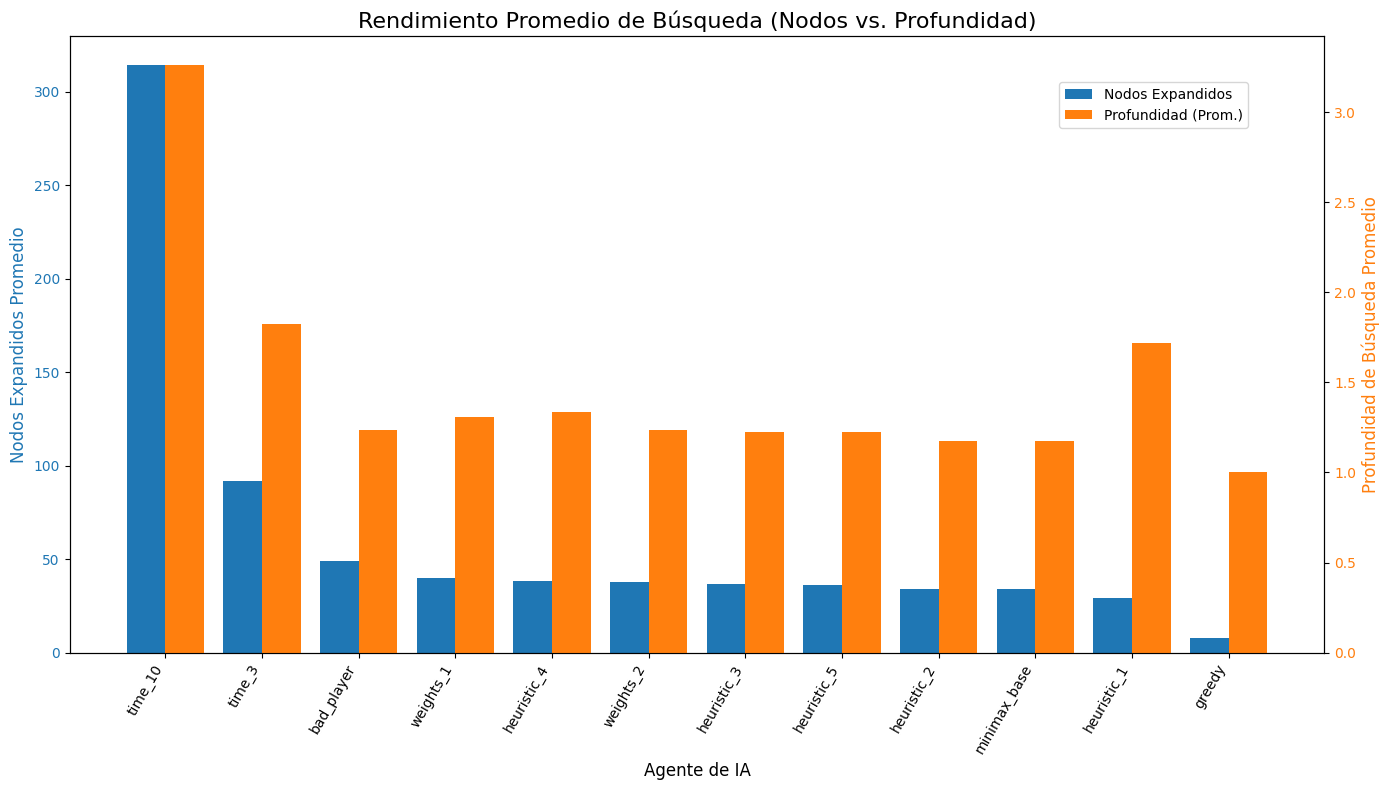

In [21]:
# 1. Preparar los datos
# Ordenamos por 'total_nodes_expanded' para una mejor visualización
df_plot = df_avg_performance.sort_values(by='total_nodes_expanded', ascending=False)

# 2. Configuración del gráfico
fig, ax1 = plt.subplots(figsize=(14, 8))
width = 0.4  # Ancho de las barras
x = np.arange(len(df_plot.index))

# 3. Eje Y primario (Izquierda) - Nodos Expandidos
color_nodes = 'tab:blue'
ax1.set_ylabel('Nodos Expandidos Promedio', color=color_nodes, fontsize=12)
bar1 = ax1.bar(x - width/2, df_plot['total_nodes_expanded'], width, label='Nodos Expandidos', color=color_nodes)
ax1.tick_params(axis='y', labelcolor=color_nodes)

# 4. Eje Y secundario (Derecha) - Profundidad de Búsqueda
# Usamos twinx() para compartir el mismo eje X
ax2 = ax1.twinx()
color_depth = 'tab:orange'
ax2.set_ylabel('Profundidad de Búsqueda Promedio', color=color_depth, fontsize=12)
bar2 = ax2.bar(x + width/2, df_plot['total_search_depth'], width, label='Profundidad (Prom.)', color=color_depth)
ax2.tick_params(axis='y', labelcolor=color_depth)

# 5. Títulos y etiquetas del eje X
ax1.set_xlabel('Agente de IA', fontsize=12)
ax1.set_title('Rendimiento Promedio de Búsqueda (Nodos vs. Profundidad)', fontsize=16)
ax1.set_xticks(x)
ax1.set_xticklabels(df_plot.index, rotation=60, ha='right')

# 6. Leyenda
# Añadimos las leyendas de ambas barras
fig.legend([bar1, bar2], ['Nodos Expandidos', 'Profundidad (Prom.)'], loc='upper right', bbox_to_anchor=(0.9, 0.9))

fig.tight_layout()  # Ajustar layout
plt.savefig('comparativa_nodos_profundidad.png')

print("Gráfico 'comparativa_nodos_profundidad.png' guardado.")

##### 4.5.2. Comparativa de Eficiencia (Uso de RAM)

Gráfico 'eficiencia_ram.png' guardado.


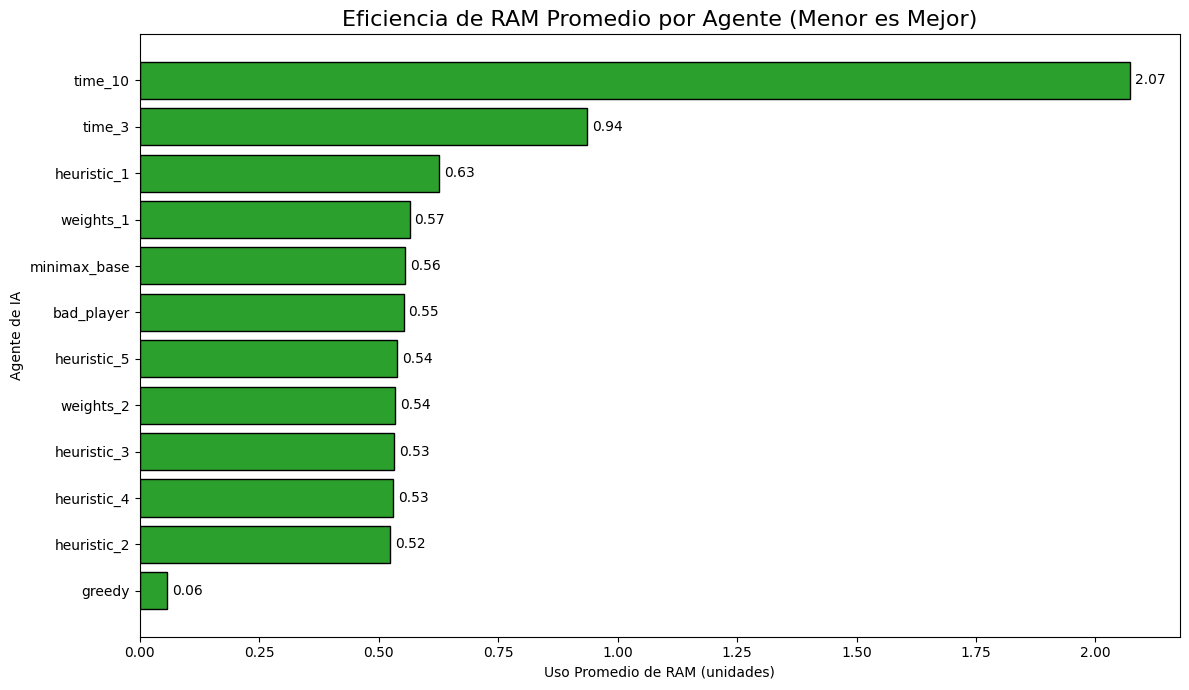

In [22]:
# 1. Preparar los datos
# Ordenamos por uso de RAM de forma ascendente (el mejor primero)
df_ram = df_avg_performance.sort_values(by='total_max_ram_usage', ascending=True)

# 2. Crear el gráfico de barras horizontales
plt.figure(figsize=(12, 7))
bars = plt.barh(df_ram.index, df_ram['total_max_ram_usage'], color='tab:green', edgecolor='black')

# 3. Títulos y etiquetas
plt.xlabel('Uso Promedio de RAM (unidades)')
plt.ylabel('Agente de IA')
plt.title('Eficiencia de RAM Promedio por Agente (Menor es Mejor)', fontsize=16)

# 4. Añadir etiquetas de valor
# Esto añade el número exacto al final de cada barra
for bar in bars:
    plt.text(
        bar.get_width() + 0.01,  # Posición X (un poco a la derecha de la barra)
        bar.get_y() + bar.get_height() / 2,  # Posición Y (centro de la barra)
        f'{bar.get_width():.2f}',  # Texto (valor formateado)
        va='center'
    )

plt.tight_layout()
plt.savefig('eficiencia_ram.png')

print("Gráfico 'eficiencia_ram.png' guardado.")

### 5. Conclusiones y Pensamientos Finales

Este análisis de benchmark nos ha permitido evaluar de forma cuantitativa el rendimiento de nuestro agente Minimax bajo un conjunto controlado de variables. Tras analizar 135 partidas, los resultados nos ofrecen una clara retroalimentación sobre el diseño de nuestro agente y la naturaleza del problema de Reversi.

#### Hallazgos Clave del Proyecto:

1.  **El Tiempo es el Recurso Dominante:**
    El hallazgo más contundente es el impacto exponencial del **tiempo de búsqueda**. El agente `time_10` (10 segundos) pudo explorar un árbol de juego aprox. 3.4 veces más grande (más nodos) y aprox. 1.8 veces más profundo que `time_3` (3 segundos). Ambos empequeñecen a los agentes de 1 segundo. Esto confirma que en un juego de búsqueda adversarial, más tiempo de cómputo se traduce directamente en una mayor profundidad táctica.

2.  **La Eficiencia de las Heurísticas (Menos es Más):**
    Dentro del grupo de agentes limitados a 1 segundo, el agente `heuristic_2` (que usaba solo 2 heurísticas: esquinas y movilidad) emergió como el **ganador más frecuente** de todo el benchmark. Además, fue el agente con el **menor consumo promedio de RAM**.
    
    Esto sugiere una conclusión clave del proyecto: en un entorno con tiempo tan limitado, una configuración de **pocas heurísticas potentes** (como esquinas y movilidad) ofrece un mejor retorno de inversión que un *stack* de 5 heurísticas (`heuristic_5`) que podría gastar más tiempo en la evaluación de cada nodo, restando tiempo a la exploración de mayor profundidad.

3.  **El Cuello de Botella del Segundo Único:**
    La restricción de 1 segundo es severa. La mayoría de estos agentes (`minimax_base`, `weights_1/2`, `heuristic_1-5`) apenas lograron una profundidad de búsqueda promedio entre 1.17 y 1.72. Esto significa que, para la mayoría de la partida, el agente operaba con una visión táctica a muy corto plazo (básicamente 1-2 movimientos hacia adelante), dependiendo fuertemente del poder de la función de evaluación estática.

4.  **El Costo de Ser "Malo":**
    Una anomalía interesante fue el rendimiento del `bad_player`. Aunque su objetivo era tomar la peor decisión, requirió una cantidad de cómputo (48.88 nodos promedio) superior a la de la mayoría de nuestros agentes optimizados (ej. `heuristic_2` con 34.04 nodos). Esto podría implicar que encontrar la "peor" jugada posible es un problema computacionalmente tan complejo como encontrar la "mejor", ya que ambos requieren una búsqueda Minimax.

### Retroalimentación Final:

El proyecto demuestra que el algoritmo Minimax con poda Alpha-Beta es robusto y funcional. Sin embargo, su éxito práctico en Reversi no depende solo de *cuántas* heurísticas se implementen, sino de *cuáles* y, sobre todo, de cuánto **tiempo** se le asigne para explorar el vasto árbol de juego.

Para futuras implementaciones, `heuristic_2` (esquinas + movilidad) con un límite de tiempo de 3 segundos (`time_3`) parece ofrecer el mejor equilibrio entre un rendimiento de victoria sólido y un costo computacional razonable.